In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pylab import rcParams
import datetime as datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import datetime as datetime
import yfinance as yf
from math import ceil
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

Data Import and Preprocessing

In [152]:
df = pd.read_csv('IBM_data.csv')

In [153]:
df.head()

,Date,Close,High,Low,Open,Volume
0,02 January 1962,1.481692,1.498529,1.481692,1.498529,407940
1,03 January 1962,1.494642,1.494642,1.481690,1.481690,305955
2,04 January 1962,1.479748,1.494643,1.479100,1.494643,274575
3,05 January 1962,1.450607,1.477806,1.448016,1.477806,384405
4,08 January 1962,1.423407,1.449311,1.411751,1.449311,572685


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15989 entries, 0 to 15988
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    15989 non-null  object 
 1   Close   15989 non-null  float64
 2   High    15989 non-null  float64
 3   Low     15989 non-null  float64
 4   Open    15989 non-null  float64
 5   Volume  15989 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 749.6+ KB


In [155]:
# Checking the size of dataset - total rows and columns:
df.shape

(15989, 6)

Missing Values Detection:

In [156]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [157]:
df.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [158]:
df.duplicated().sum()

np.int64(0)

In [159]:
df.describe()

,Close,High,Low,Open,Volume
count,15989.000000,15989.000000,15989.000000,15989.000000,1.598900e+04
mean,41.077649,41.434909,40.699244,41.056811,5.069369e+06
std,48.765527,49.145565,48.322436,48.720486,4.574276e+06
min,0.792886,0.833048,0.777339,0.792886,0.000000e+00
25%,4.035865,4.064186,4.006179,4.033436,1.586573e+06
50%,11.722463,11.821408,11.619156,11.740191,4.272282e+06
75%,68.086777,68.553743,67.234517,67.886633,6.972218e+06
max,294.779999,296.160004,290.359985,294.549988,7.263916e+07


In [160]:
# Converting the Date column from Object data type to Datetime64 format:
df.Date = pd.to_datetime(df.Date)

# Getting the basic information after dtype change:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15989 entries, 0 to 15988
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    15989 non-null  datetime64[ns]
 1   Close   15989 non-null  float64       
 2   High    15989 non-null  float64       
 3   Low     15989 non-null  float64       
 4   Open    15989 non-null  float64       
 5   Volume  15989 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 749.6 KB


Data Cleaning and Formatting

In [161]:
# adding a few more columns to our dataset -  containing the year, month name, and weekday name
df['Year'] = pd.DatetimeIndex(df['Date']).year
df['Month'] = pd.DatetimeIndex(df['Date']).month_name()
df['Weekday'] = pd.DatetimeIndex(df['Date']).day_name()  # day_name is a function in pandas

# setting the Date column as index for the dataset:
df.set_index('Date',inplace=True)

# getting a snapshot of first 5 rows of dataset:
df.head()

,Close,High,Low,Open,Volume,Year,Month,Weekday
Date,,,,,,,,
1962-01-02,1.481692,1.498529,1.481692,1.498529,407940,1962,January,Tuesday
1962-01-03,1.494642,1.494642,1.481690,1.481690,305955,1962,January,Wednesday
1962-01-04,1.479748,1.494643,1.479100,1.494643,274575,1962,January,Thursday
1962-01-05,1.450607,1.477806,1.448016,1.477806,384405,1962,January,Friday
1962-01-08,1.423407,1.449311,1.411751,1.449311,572685,1962,January,Monday


In [162]:
df.tail()

,Close,High,Low,Open,Volume,Year,Month,Weekday
Date,,,,,,,,
2025-07-08,290.420013,295.609985,289.489990,293.100006,2925300,2025,July,Tuesday
2025-07-09,290.140015,291.600006,288.630005,291.390015,2971300,2025,July,Wednesday
2025-07-10,287.429993,288.899994,282.209992,288.899994,3487800,2025,July,Thursday
2025-07-11,283.589996,287.429993,282.920013,285.010010,3790700,2025,July,Friday
2025-07-14,283.790008,284.929993,281.709992,282.829987,2857100,2025,July,Monday


Exploratory Data Analysis (EDA) 

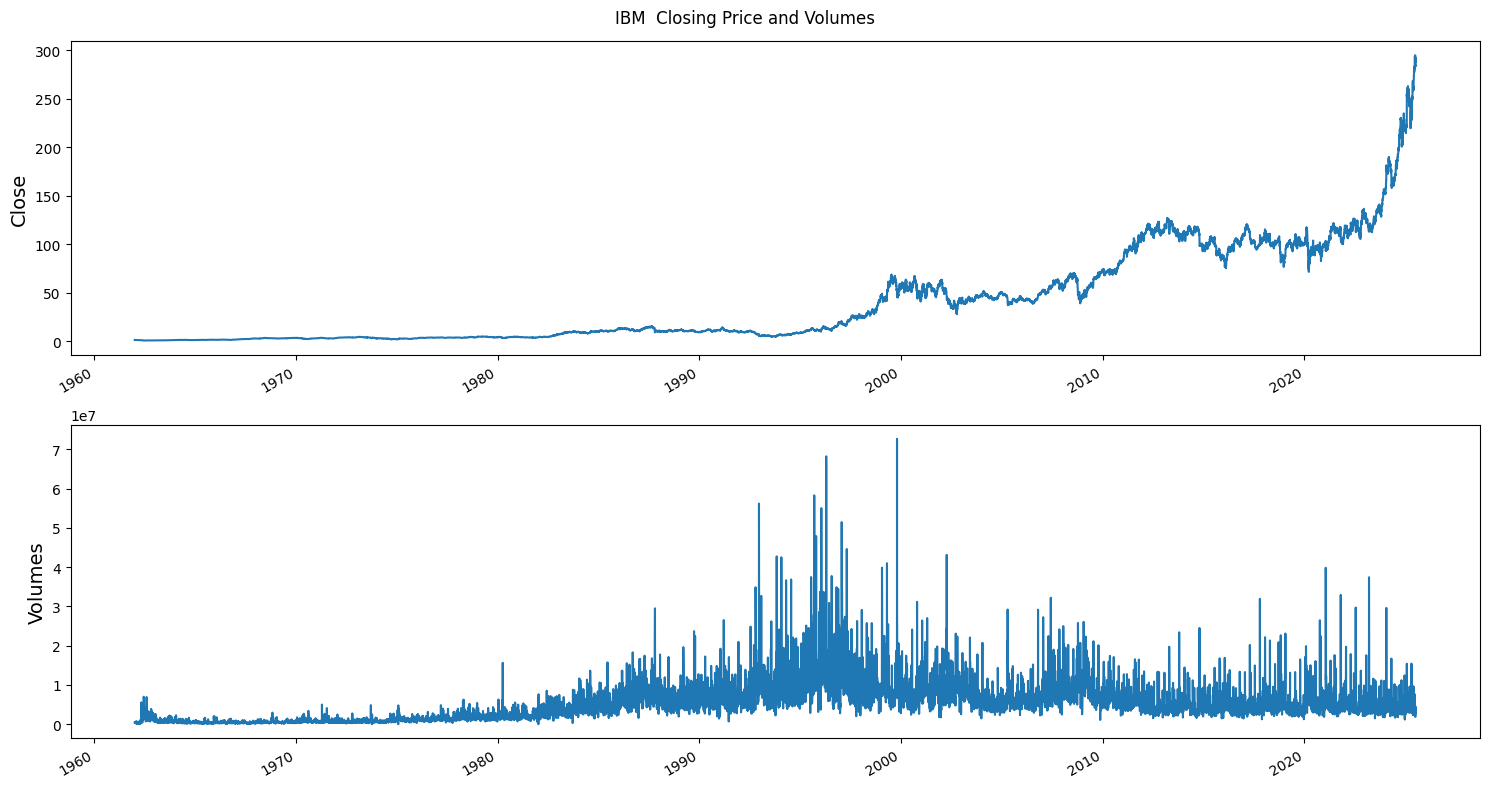

In [163]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Plotting Amazon's adjusted closing price as a line plot:
df['Close'].plot(ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('Close',fontsize=14)

# Creating a line plot for Amazon's stock Volumes:
df['Volume'].plot(ax=axes[1])
axes[1].set_ylabel('Volumes', fontsize=14)
axes[1].set_xlabel('')  # to get nothing in x axis as labels

plt.suptitle('IBM  Closing Price and Volumes')
plt.tight_layout()
plt.show()

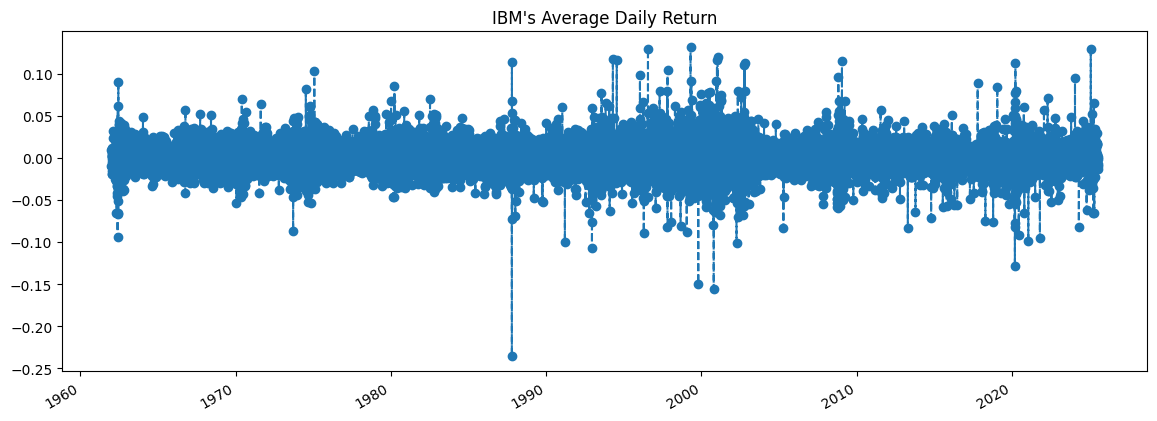

In [164]:
# Calculating the returns for IBM stock using the percent change or pct_change() function:
df['returns'] = df['Close'].pct_change()
df['returns'].plot(figsize=(14,5),linestyle='--',marker='o')
plt.xlabel('')
plt.title("IBM's Average Daily Return")
plt.show()

Visualizing Movements in IBM Volumes by Weekdays and by Months -

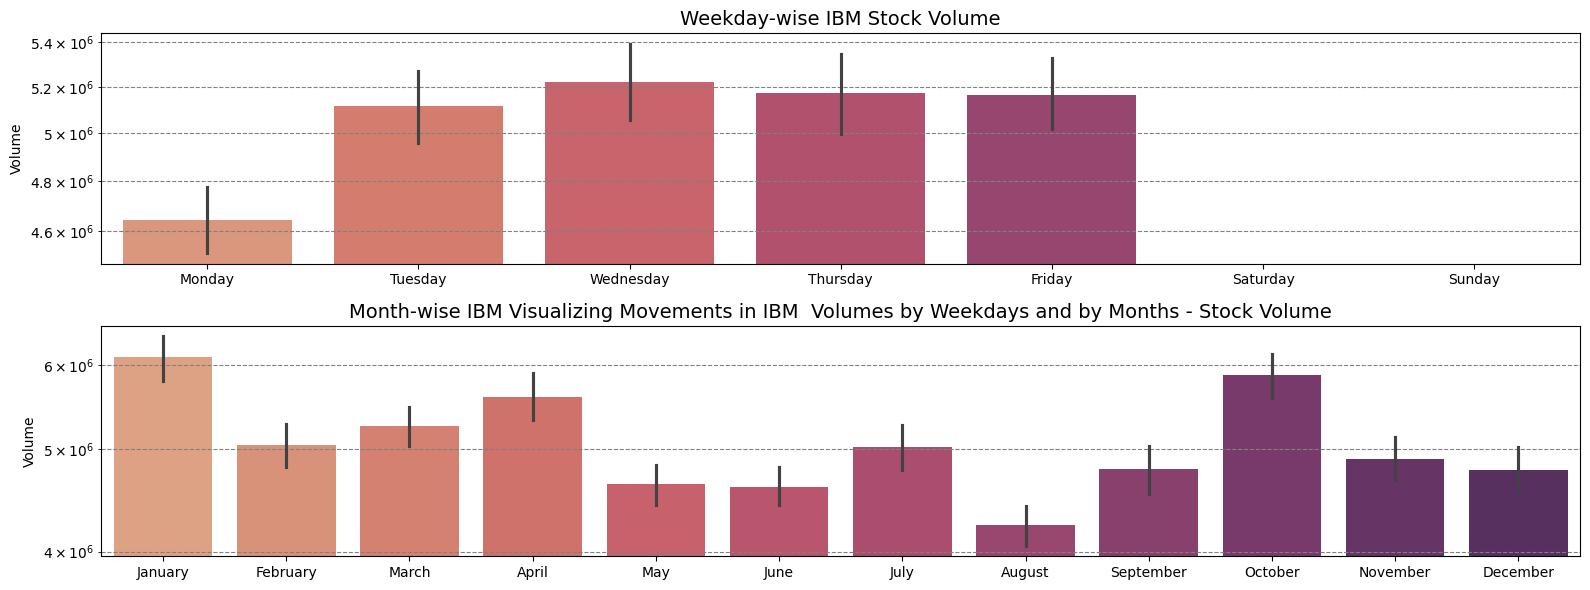

In [165]:

# Visualizing Movements in Amazon Volumes by Weekdays and by Months as Bar Subplots- 
fig, axes = plt.subplots(2, 1, figsize=(16, 6))

# specifying the order of bar plots for weekdays:
order = [ "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday","Sunday"]
sns.barplot(x=df.Weekday, y=df.Volume, palette="flare",ax=axes[0], order =order)
axes[0].set_title("Weekday-wise IBM Stock Volume",fontsize=14)
axes[0].set_yscale("log") 
axes[0].set_ylabel("Volume",fontsize=10)
axes[0].set_xlabel("",fontsize=10)
axes[0].grid(which="minor",color="grey", linestyle="--")

# specifying the order of bar plots for Months:
order2 = [ "January", "February", "March", "April", "May", "June","July", 'August', 'September', 'October', 'November', 'December']
sns.barplot(x=df.Month, y=df.Volume, palette="flare",ax=axes[1], order = order2)
axes[1].set_title("Month-wise IBM Visualizing Movements in IBM  Volumes by Weekdays and by Months - Stock Volume",fontsize=14)
axes[1].set_yscale("log")
axes[1].set_ylabel("Volume",fontsize=10)
axes[1].set_xlabel("",fontsize=10)
axes[1].grid(which="minor",color="grey", linestyle="--")

plt.tight_layout()
plt.show()

Plotting the Mean of Amazon Daily Closing Price at the Start of every Year -

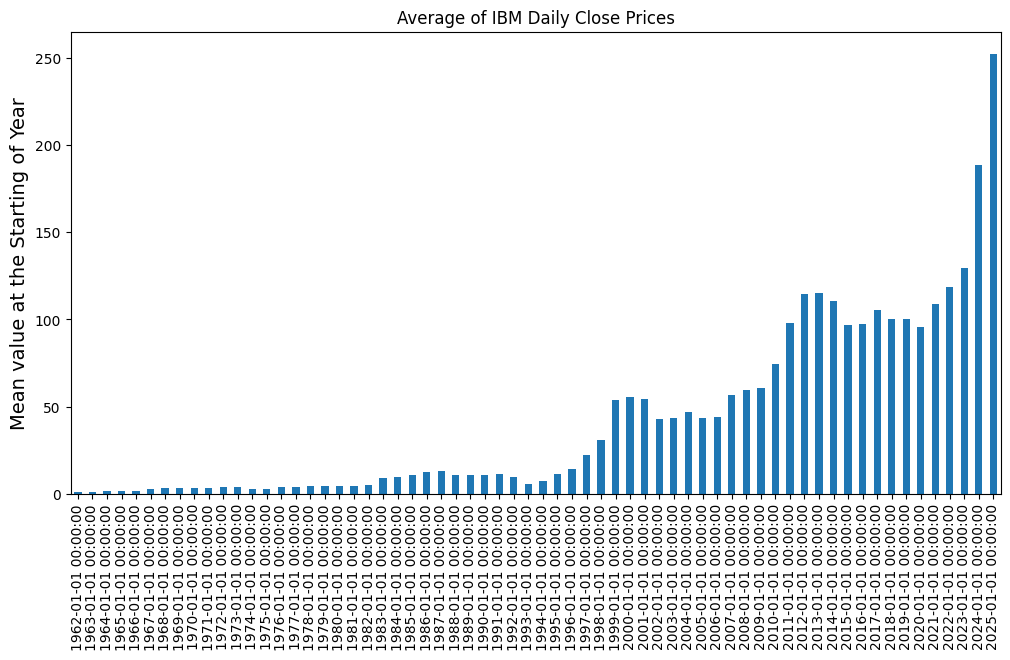

In [166]:
# First, creating a copy of amazon dataset:
rolling_ibm = df.copy()

# Plotting a bar for the mean of starting of every year for Amazon stock - 
ax = rolling_ibm.Close.resample(rule='AS').mean().plot.bar(figsize=(12,6))

# setting the title for the plot:
ax.set(title='Average of IBM Daily Close Prices')
plt.ylabel('Mean value at the Starting of Year',size=14)
plt.xlabel('')
plt.show()

Exploring the Correlation between Different IBM  Daily Prices -

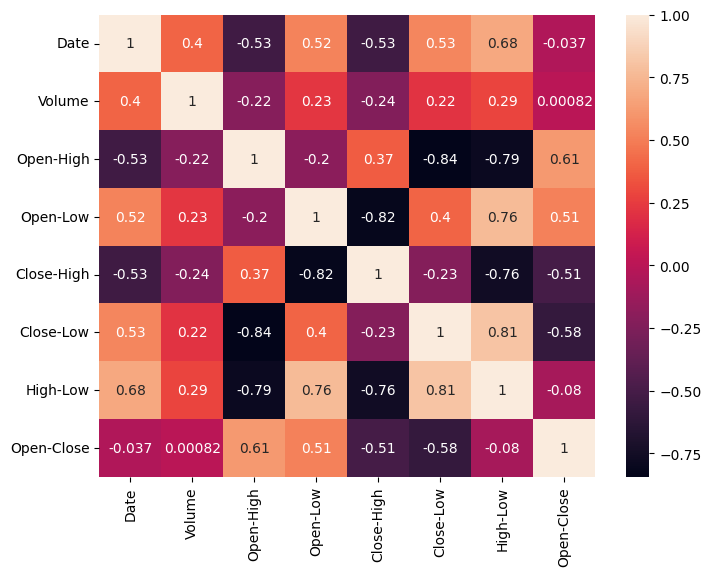

In [167]:
# firstly, we crete a copy of the Amazon datasset:
ibm_corr_df = df.copy()
ibm_corr_df.reset_index(inplace=True)

# Feature engineering - adding new columns to the new dataset created:
ibm_corr_df['Open-High'] = ibm_corr_df['Open']-ibm_corr_df['High']
ibm_corr_df['Open-Low'] = ibm_corr_df['Open'] - ibm_corr_df['Low']
ibm_corr_df['Close-High'] = ibm_corr_df['Close']-ibm_corr_df['High']
ibm_corr_df['Close-Low'] = ibm_corr_df['Close'] -ibm_corr_df['Low']
ibm_corr_df['High-Low'] = ibm_corr_df['High'] - ibm_corr_df['Low']
ibm_corr_df['Open-Close'] = ibm_corr_df['Open'] - ibm_corr_df['Close']

# Creating a heatmap to visualize the correlation among different Daily price columns for Amazon stocks:
ibm_corr_df2 = ibm_corr_df.copy()
ibm_corr_df2 = ibm_corr_df2.drop(['Open','High','Low','Close','Year', 'Month', 'Weekday','returns'],axis=1)
plt.figure(figsize=(8,6))
sns.heatmap(ibm_corr_df2.corr(),annot=True)
plt.show()

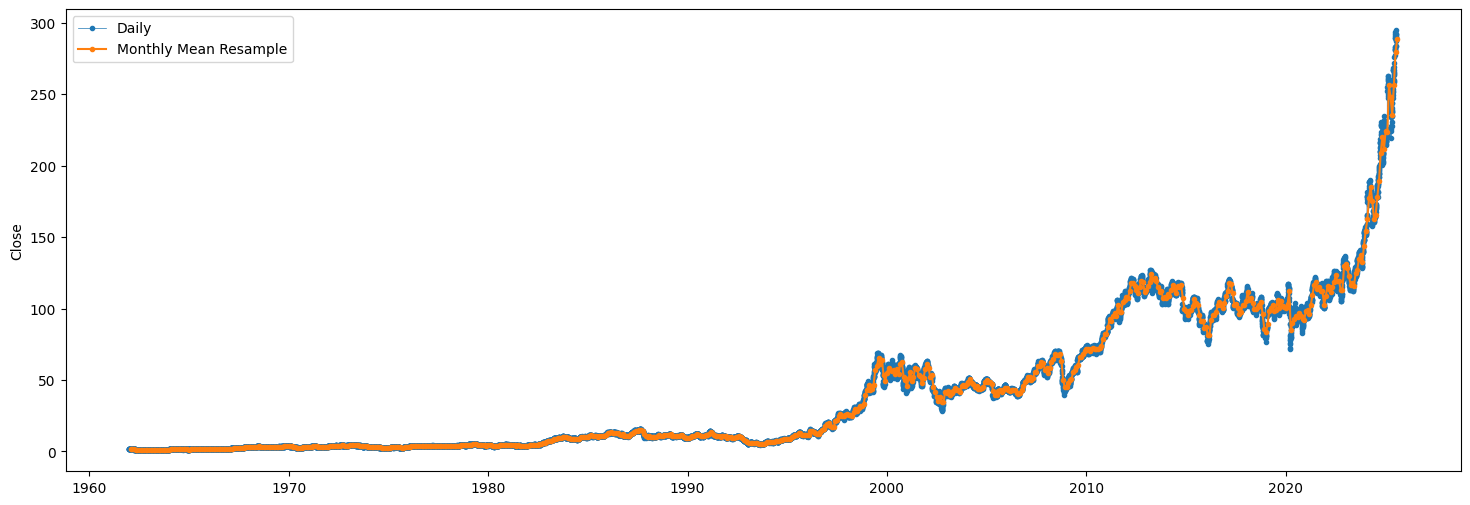

In [168]:
# Visualizing the Daily Adjusted Close and the Monthly Average resampled data for Amazon:
fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(df['Close'],marker='.', linestyle='-', linewidth=0.5, label='Daily')
ax.plot(df['Close'].resample('M').mean(),marker='o', markersize=3, linestyle='-', label='Monthly Mean Resample')
ax.set_ylabel('Close')
ax.legend()
plt.show()

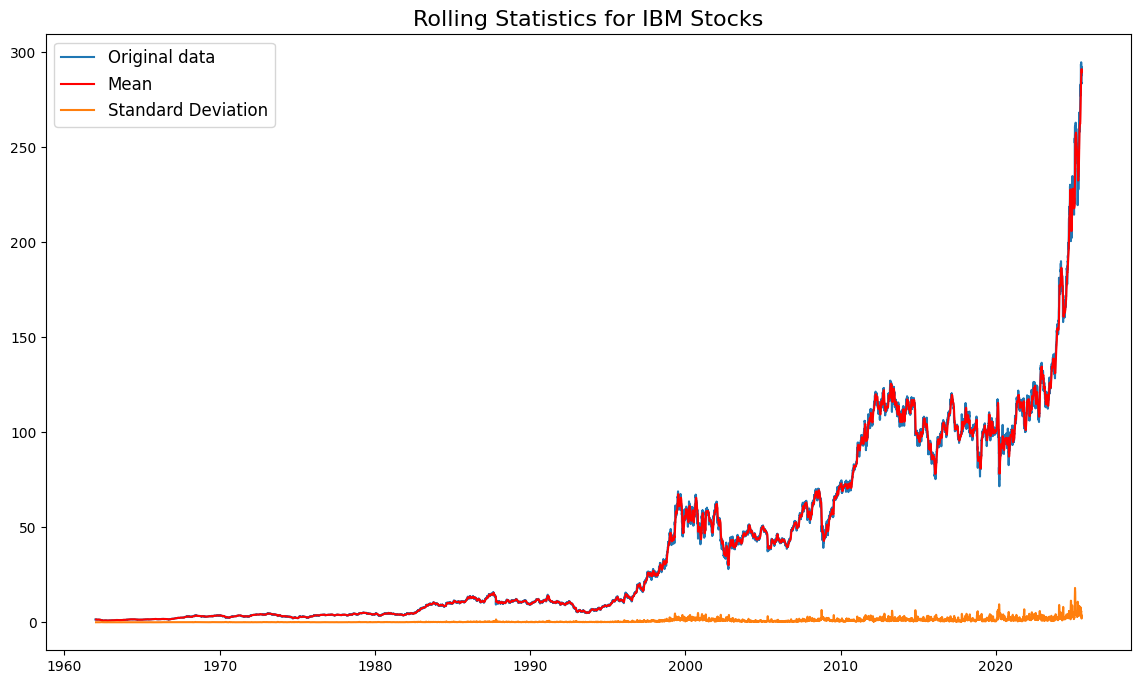

In [169]:
# Determining the rolling statistics for IBM time series -
IBM= df['Close']

# calculating the rolling mean and standard deviation with window sizes of 12: 
roll_mean =IBM.rolling(12).mean() 
roll_std = IBM.rolling(12).std()

# plotting the rolling statistics alongwith the original data for IBM  stock: 
fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(df['Close'], label= 'Original data')
ax.plot(roll_mean, label='Mean',color='red')
ax.plot(roll_std, label='Standard Deviation')
plt.title('Rolling Statistics for IBM Stocks', fontsize=16)
ax.legend(fontsize=12)
plt.show()

prophet forecasting

In [181]:
from prophet import Prophet

df = df.reset_index()[['Date','Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

#Fit the model
model=Prophet()
model.fit(df)

future=model.make_future_dataframe(periods=365)

#Prediction
forecast=model.predict(future)

#Plot the forecasting
model.plot(forecast)
plt.title('IBM Stock Price Pred')
plt.show()

KeyError: "['Close'] not in index"

In [182]:
df.head()

,Open
Date,
1962-01-02,1.498529
1962-01-03,1.481690
1962-01-04,1.494643
1962-01-05,1.477806
1962-01-08,1.449311


ARIMA Forecasting (using statsmodels)

----------------------------------------------------------
-----------STOCK PRICE PREDICTION BY ARIMA ---------------
----------------------------------------------------------
Shape of Training Set: (14391, 1)
Shape of Validation Set: (1598, 1)
RMSE value on validation set: nan
----------------------------------------------------------


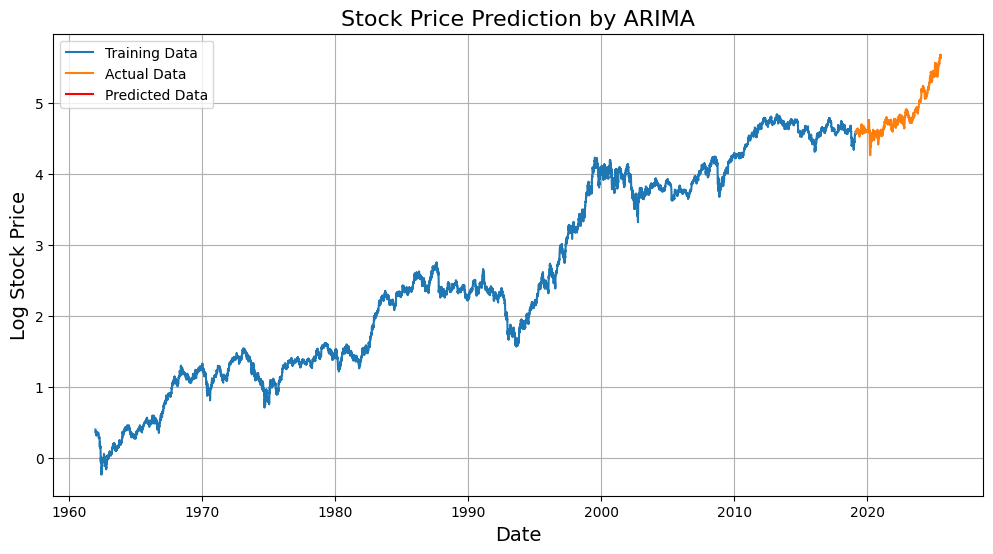

In [172]:
# 📈 ARIMA Forecasting Function
def moving_avg_prediction(data):
    shape = data.shape[0]
    df_new = data[['Open']].copy()
    df_new['Open'] = np.log(df_new['Open'])  # Log transform

    # 🧪 Train/Validation Split
    train_set = df_new.iloc[:ceil(shape * 0.9)]
    valid_set = df_new.iloc[ceil(shape * 0.9):]

    print('----------------------------------------------------------')
    print('-----------STOCK PRICE PREDICTION BY ARIMA ---------------')
    print('----------------------------------------------------------')
    print('Shape of Training Set:', train_set.shape)
    print('Shape of Validation Set:', valid_set.shape)

    training = train_set['Open']
    validation = valid_set['Open']

    # ⚙️ Fit ARIMA(p,d,q) model (You can change (p,d,q) based on tuning)
    model = ARIMA(training, order=(5, 1, 0))  # Example: (5,1,0)
    model_fit = model.fit()

    # 🔮 Forecast
    forecast = model_fit.forecast(steps=len(validation))
    forecast = pd.DataFrame(forecast, index=validation.index, columns=['Prediction'])

    # 📉 RMSE
    rms = np.sqrt(np.mean((validation - forecast['Prediction']) ** 2))
    print('RMSE value on validation set:', rms)
    print('----------------------------------------------------------')

    # 📊 Plot
    plt.figure(figsize=(12, 6))
    plt.plot(train_set['Open'], label='Training Data')
    plt.plot(validation, label='Actual Data')
    plt.plot(forecast['Prediction'], label='Predicted Data', color='red')
    plt.xlabel('Date', size=14)
    plt.ylabel('Log Stock Price', size=14)
    plt.title('Stock Price Prediction by ARIMA', size=16)
    plt.legend()
    plt.grid(True)
    plt.show()

# 📥 Load IBM Stock Data from CSV
df = pd.read_csv('IBM_data.csv')  # Replace with your actual CSV file
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df[['Open']].dropna()

# 🧠 Run the prediction
moving_avg_prediction(df)



SARIMA Forecasting

----------------------------------------------------------
-----------STOCK PRICE PREDICTION BY SARIMA--------------
----------------------------------------------------------
Shape of Training Set: (14391, 1)
Shape of Validation Set: (1598, 1)
RMSE value on validation set: nan
-----------------------------------------------------------


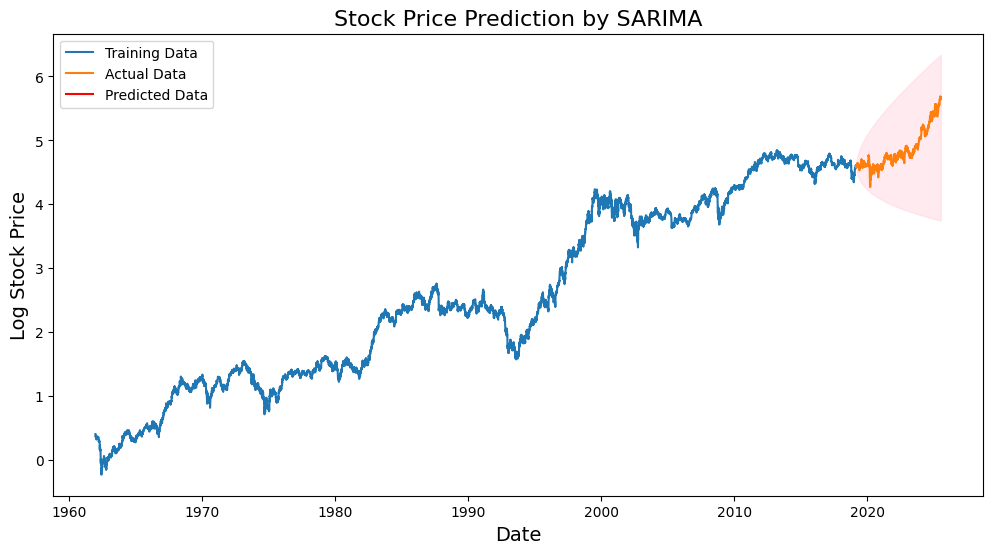

In [173]:
def sarima_prediction(data):
    shape = data.shape[0]
    
    # Create a copy to avoid warnings
    df_new = data[['Open']].copy()
    df_new['Open'] = np.log(df_new['Open'])  # Apply log transformation
    
    # Split data
    train_set = df_new.iloc[:ceil(shape * 0.9)]
    valid_set = df_new.iloc[ceil(shape * 0.9):]
    
    print('----------------------------------------------------------')
    print('-----------STOCK PRICE PREDICTION BY SARIMA--------------')
    print('----------------------------------------------------------')
    print('Shape of Training Set:', train_set.shape)
    print('Shape of Validation Set:', valid_set.shape)

    training = train_set['Open']
    validation = valid_set['Open']

    # Define SARIMA model
    model = SARIMAX(training,
                    order=(1, 1, 1),
                    seasonal_order=(1, 1, 1, 12),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    results = model.fit(disp=False)
    
    # Forecast
    forecast = results.get_forecast(steps=len(validation))
    forecast_index = valid_set.index
    forecast_mean = forecast.predicted_mean
    forecast_conf_int = forecast.conf_int()
    
    forecast_df = pd.DataFrame(forecast_mean, index=forecast_index, columns=['Prediction'])

    # Calculate RMSE
    rms = np.sqrt(np.mean(np.power(validation - forecast_df['Prediction'], 2)))
    print('RMSE value on validation set:', rms)
    print('-----------------------------------------------------------')
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(train_set['Open'], label='Training Data')
    plt.plot(valid_set['Open'], label='Actual Data')
    plt.plot(forecast_df['Prediction'], label='Predicted Data', color='red')
    plt.fill_between(forecast_index,
                     forecast_conf_int.iloc[:, 0],
                     forecast_conf_int.iloc[:, 1],
                     color='pink', alpha=0.3)
    plt.xlabel('Date', size=14)
    plt.ylabel('Log Stock Price', size=14)
    plt.title('Stock Price Prediction by SARIMA', size=16)
    plt.legend()
    plt.show()

# 📥 Load IBM stock data from local CSV
df = pd.read_csv('IBM_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df[['Open']].dropna()

# 📈 Run SARIMA prediction
sarima_prediction(df)



LSTM Forecasting  (using TensorFlow / Keras)

In [183]:
# 📥 Load Data
data = pd.read_csv('stock_data.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

#Prepare for Prophet
# Instead of selecting 'Date' as a column, reset the index
# and then select 'Date' and 'Close'
df = data.reset_index()[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})

# Prepare Data
# Print the shape of 'data' to check if it's empty
print("Shape of data:", data.shape)
scaler = MinMaxScaler(feature_range=(0,1))
# scaled_data = scaler.fit_transform(data.values.reshape(-1,1))
# Check if 'data.values' is empty before reshaping
if data.empty:
    print("Error: 'data' DataFrame is empty. Please check data loading or preprocessing.")
else:
    # *** The Fix: Select only the 'Close' column for scaling ***
    scaled_data = scaler.fit_transform(data[['Close']].values.reshape(-1,1))


# Split into train/test
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create sequences
def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X_train, y_train = create_dataset(train, time_step)
X_test, y_test = create_dataset(test, time_step)

# Reshape for LSTM input (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1], 1)

# Build LSTM Model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train
model.fit(X_train, y_train, epochs=20, batch_size=32)

# Predict
train_predict = model.predict(X_train)
test_predict  = model.predict(X_test)

# Inverse Scaling
train_predict = scaler.inverse_transform(train_predict)
test_predict  = scaler.inverse_transform(test_predict)

# Plot
plt.plot(data.index, data['Close'], label='Actual') # Changed data.values to data['Close']
plt.plot(data.index[time_step:len(train_predict)+time_step], train_predict, label='Train Predict')
plt.plot(data.index[len(train_predict)+(time_step*2)+1:len(data)-1], test_predict, label='Test Predict')
plt.title('LSTM Forecast')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'tensorflow'